In [1]:
import pandas as pd
import numpy as np
from Autograd import Tensor
import matplotlib.pyplot as plt
from Model import Linear,Sequential,Layernorm,Embedding
from Activation import ReLU
from Loss import cross_entropy_loss, mean_squared_error
from Training import training, mean_squared_error, cross_entropy_loss
from Data import testing_data_processing, training_data_processing
from Testing import classification_accuracy
from Optimiser import SGD

Using the original Layer Norm paper linked below as a basis, I implemented the layer norm. Emperically it has been shown that layer norm can increase speed of convergence during gradient descent.

We perform z-score standardisation across the feature dimensions on the output of a linear layer. So each sample has its own respective mean and standard deviation for each layer norm applied. As defined by the paper we use the population standard deviation.
After this, we apply an affine transformation on the standardised outputs, where the parameters for this are leared through gradient descent.

The original paper focused on its use in RNNs, however, I have used it in my MLP implementation. The layer norm is also used in the transformer architecture from 'Attention is all you need'.


https://arxiv.org/pdf/1607.06450

In [2]:
normalisedfeatures,price_range,columnmean,columnstd,nofeatures,noclasses,nosamples=training_data_processing()

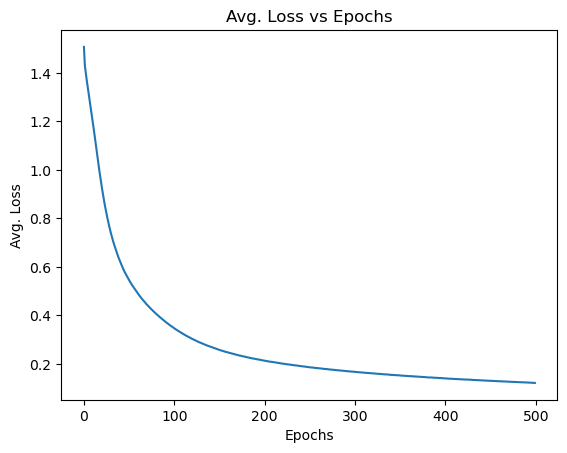

0.12156165032776721


In [3]:
GD_model=Sequential([Linear(nofeatures,10), ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_loss
optimiser=SGD(GD_model.parameters(),0.005)
GD_losses=training(normalisedfeatures,GD_model,price_range,loss_fn,500,optimiser,32)
plt.plot(GD_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()
print(GD_losses[-1])

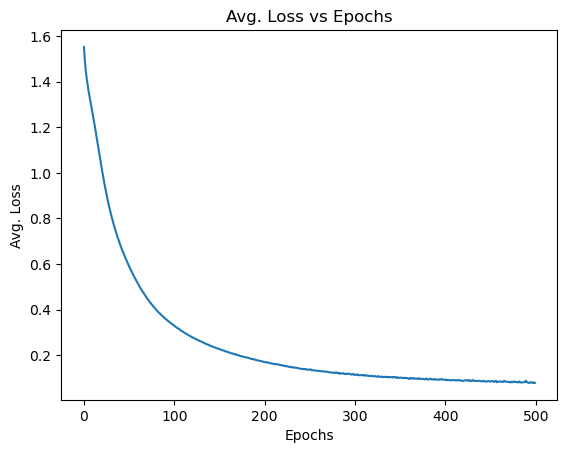

0.07815636047660401


In [4]:
GD_model=Sequential([Linear(nofeatures,10), Layernorm(10),ReLU(),Linear(10,noclasses)])
loss_fn=cross_entropy_loss
optimiser2=SGD(GD_model.parameters(),0.005)
GD_losses=training(normalisedfeatures,GD_model,price_range,loss_fn,500,optimiser2,32)
plt.plot(GD_losses)
plt.xlabel("Epochs")
plt.ylabel("Avg. Loss")
plt.title("Avg. Loss vs Epochs")
plt.show()
print(GD_losses[-1])

We can see from the results that after 500 epochs of 32 batch-size SGD, the loss when using Layer norm is 0.0781 compared to 0.122 without, so we have likely converged faster using the layer norm.

Combining layer norm with other optimisation techniques like momentum or AdaGrad can likely further improve performance of training.

There exists many hypothesis for why layer norm may improve speed of convergence. One such hypothesis is that layer norm keeps the parameter scaling consistent throughout the model, hence the gradients used in SGD remain stable. There is, however, no universally agreed hypothesis.